In [21]:
# word2vecの高速化
# word2vecの改良１
# Embeddingレイヤ

In [22]:
# Embeddingレイヤの実装
import numpy as np
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        
        for i, word_id in enumerate(self.idx):
            dW[word_id] += dout[i]

        return None

In [23]:
# word2vecの改良２
# 中間層以降の計算の問題点
# 多値分類から二値分類へ
# シグモイド関数と交差エントロピー誤差

In [24]:
# 多値分類から二値分類へ（実装編）
# Embedding Dotレイヤの実装
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

In [25]:
# Negative Sampling
# Negative Samplingのサンプリング手法
# Negative Samplingの実装
import sys
sys.path.append("..")
from common.layers import SigmoidWithLoss
from negative_sampling_layer import UnigramSampler

class NegativeSamplingLoss:
    def __init__ (self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 正例のフォワード
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 負例のフォワード
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

In [ ]:
# 改良版word2vecの学習
# CBOWモデルの実装
import sys
sys.path.append("..")
from common.layers import Embedding
from negative_sampling_layer import NegativeSamplingLoss

rng = np.random.default_rng()

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * rng.random((V, H)).astype("f")
        W_out = 0.01 * rng.random((V, H)).astype("f")

        # レイヤの生成
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 全ての重みと勾配を配列にまとめる
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

| epoch 1 |  iter 1 / 9295 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 9295 | time 1[s] | loss 4.16
| epoch 1 |  iter 41 / 9295 | time 2[s] | loss 4.15
| epoch 1 |  iter 61 / 9295 | time 3[s] | loss 4.12
| epoch 1 |  iter 81 / 9295 | time 4[s] | loss 4.04
| epoch 1 |  iter 101 / 9295 | time 5[s] | loss 3.92
| epoch 1 |  iter 121 / 9295 | time 6[s] | loss 3.78
| epoch 1 |  iter 141 / 9295 | time 7[s] | loss 3.63
| epoch 1 |  iter 161 / 9295 | time 8[s] | loss 3.49
| epoch 1 |  iter 181 / 9295 | time 9[s] | loss 3.36
| epoch 1 |  iter 201 / 9295 | time 10[s] | loss 3.27
| epoch 1 |  iter 221 / 9295 | time 11[s] | loss 3.18
| epoch 1 |  iter 241 / 9295 | time 12[s] | loss 3.08
| epoch 1 |  iter 261 / 9295 | time 13[s] | loss 3.01
| epoch 1 |  iter 281 / 9295 | time 14[s] | loss 2.96
| epoch 1 |  iter 301 / 9295 | time 15[s] | loss 2.94
| epoch 1 |  iter 321 / 9295 | time 16[s] | loss 2.89
| epoch 1 |  iter 341 / 9295 | time 17[s] | loss 2.82
| epoch 1 |  iter 361 / 9295 | time 18[s] | 

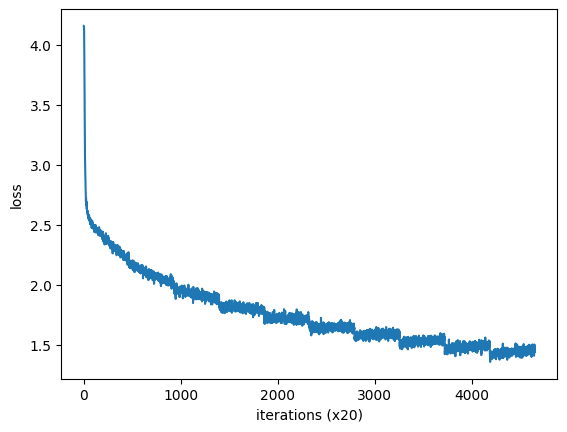

In [29]:
# CBOWモデルの学習コード
import sys
sys.path.append("..")
from common import config
config.GPU = False
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from cbow import CBOW
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb

# ハイパーパラメータの設定
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data("train")
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# モデルなどの生成
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 後ほど利用できるように、必要なデータを保存
word_vecs = model.word_vecs